# pymodal — End-to-end demo

Covers the full pipeline from synthetic structural-health data to a trained
PyTorch classifier on the **post-refactor API**, where `frf` and
`timeseries` are themselves `_collection_1d` subclasses (no separate
`frf_collection` / `timeseries_collection` / `IndicatorCollection`).

| Section | pymodal feature |
|---|---|
| 1 | Synthetic SDOF accelerance FRFs |
| 2 | `frf` — single-item construction, plotting, processing |
| 3 | `timeseries` — time-domain construction, processing, augmentation |
| 4 | `frf` collection — multi-item, batch operations, HDF5 persistence |
| 5 | `HDF5Dataset` + PyTorch `DataLoader` |
| 6–8 | 1-D CNN training with gradient accumulation and mixed precision |
| 10 | `cfdac_collection` — typed 2-D indicator, 2-D CNN, baseline comparison |

> **Environment**: `numpy`, `scipy`, `matplotlib`, `pint`, `pyFRF`, `h5py`,
> `audiomentations`, `torch`. `scikit-learn` is **not** required; the
> confusion matrix is built manually.

In [1]:
import sys, subprocess, inspect

def _has_post_refactor_api():
    try:
        import pymodal
        # Feature check: post-refactor frf.__init__ accepts a `path` kwarg.
        return "path" in inspect.signature(pymodal.frf.__init__).parameters
    except Exception:
        return False


if not _has_post_refactor_api():
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                           "pyFRF>=0.40", "pint>=0.20.1", "audiomentations>=0.31.0"])
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                           "--no-deps", "--force-reinstall", "--no-cache-dir",
                           "git+https://github.com/grcarmenaty/pymodal.git@master"])
    import IPython
    IPython.Application.instance().kernel.do_shutdown(restart=True)
else:
    import pymodal
    print("pymodal", pymodal.__version__, "ready (post-refactor API detected).")


pymodal 0.2.0 ready (post-refactor API detected).


## 0 · Imports and device

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

import pymodal
from pymodal import frf, timeseries

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RNG = np.random.default_rng(42)

print(f"Device  : {DEVICE}")
print(f"PyTorch : {torch.__version__}")
print(f"pymodal : {pymodal.__version__}")

Device  : cpu
PyTorch : 2.11.0+cu130
pymodal : 0.2.0


## 1 · Synthetic data — SDOF accelerance FRFs

Three structural-health states, 90 realisations each, with ±3 % unit-to-unit
scatter on mass and stiffness.

| Class | Label | Change |
|---|---|---|
| Healthy | 0 | — |
| Cracked | 1 | −10 % stiffness, +75 % damping |
| Loose   | 2 | +10 % mass |

Analytical accelerance:
$$H(\omega) = \frac{-\omega^2}{k - m\omega^2 + j c\omega}$$

In [3]:
FS  = 100.0
DT  = 1.0 / FS
T   = 10.0
t   = np.arange(0, T, DT)
N   = len(t)

DF    = 1.0 / T
freqs = np.arange(0, FS / 2 + DF, DF)
omega = 2 * np.pi * freqs

print(f"Time  : {N} samples @ {FS} Hz  →  {T} s")
print(f"Freq  : {len(freqs)} bins,  0–{freqs[-1]:.0f} Hz,  Δf = {DF} Hz")

Time  : 1000 samples @ 100.0 Hz  →  10.0 s
Freq  : 501 bins,  0–50 Hz,  Δf = 0.1 Hz


In [4]:
CLASS_DEFS = [
    {"label": 0, "tag": "Healthy", "m": 1.00, "k": 400.0, "zeta": 0.020},
    {"label": 1, "tag": "Cracked", "m": 1.00, "k": 360.0, "zeta": 0.035},
    {"label": 2, "tag": "Loose",   "m": 1.10, "k": 400.0, "zeta": 0.020},
]
N_PER_CLASS = 90


def sdof_accelerance(omega, m, k, zeta):
    c = 2 * zeta * np.sqrt(k * m)
    return -omega**2 / (k - m * omega**2 + 1j * c * omega)


H_all, labels_all, names_all = [], [], []
for cls in CLASS_DEFS:
    for i in range(N_PER_CLASS):
        mk = RNG.uniform(0.97, 1.03)
        kk = RNG.uniform(0.97, 1.03)
        H = sdof_accelerance(omega, cls["m"] * mk, cls["k"] * kk, cls["zeta"])
        H_all.append(H[:, np.newaxis, np.newaxis].astype(np.complex64))
        labels_all.append(float(cls["label"]))
        names_all.append(f"{cls['tag']}_{i:03d}")

print(f"Generated {len(H_all)} FRFs  ({N_PER_CLASS} per class)")
print(f"Per-FRF array shape: {H_all[0].shape}  (n_freq, n_outputs, n_inputs)")

Generated 270 FRFs  (90 per class)
Per-FRF array shape: (501, 1, 1)  (n_freq, n_outputs, n_inputs)


## 2 · Single-item `frf`

`frf` is a `_collection_1d` subclass with frequency as the domain axis.
Passing a single 3-D ndarray yields a 1-item collection — a thin
self-contained HDF5 file with one measurement, one set of channel/DOF
metadata, and a frequency axis.

In [5]:
demo_frfs = [
    frf(
        measurements=H_all[cls["label"] * N_PER_CLASS],
        freq_resolution=DF,
        measurements_units="millimeter / second**2 / newton",
        freq_units="hertz",
        method="SIMO",
        name=cls["tag"],
        path=Path(f"./_demo_{cls['tag']}.h5"),
    )
    for cls in CLASS_DEFS
]

f0 = demo_frfs[0]
print(f"len(f0)            : {len(f0)}                         (number of items)")
print(f"f0.measurements[0] : shape={f0.measurements[0].shape}  (1 item)")
print(f"f0.freq_array      : shape={f0.freq_array.shape}, [0]={f0.freq_array[0]}, [-1]={f0.freq_array[-1]}")
print(f"f0.freq_resolution : {f0.freq_resolution}")
print(f"f0.dof             : {f0.dof}")
print(f"f0.measurements_units: {f0.measurements_units!r}")

len(f0)            : 1                         (number of items)
f0.measurements[0] : shape=(501, 1, 1)  (1 item)
f0.freq_array      : shape=(501,), [0]=0.0, [-1]=50.0
f0.freq_resolution : 0.1
f0.dof             : 1
f0.measurements_units: 'millimeter / second**2 / newton'


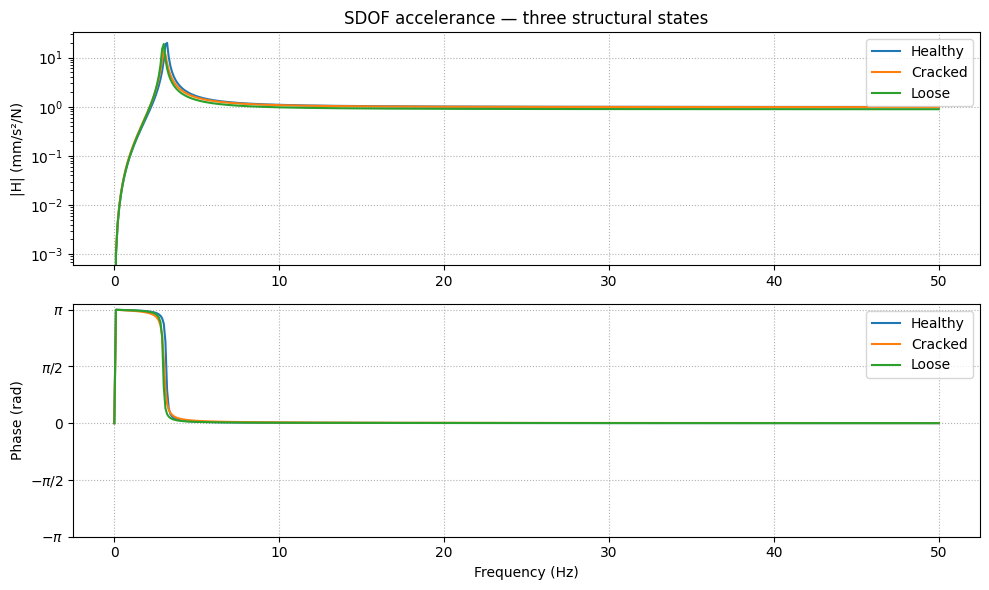

In [6]:
# Magnitude + phase of the three demo FRFs
fig, axes = plt.subplots(2, 1, figsize=(10, 6))
for f_obj, cls in zip(demo_frfs, CLASS_DEFS):
    arr = f_obj.measurements[0][()][:, 0, 0]   # complex spectrum, item 0
    axes[0].semilogy(f_obj.freq_array, np.abs(arr),  label=cls["tag"])
    axes[1].plot   (f_obj.freq_array, np.angle(arr), label=cls["tag"])
axes[0].set(ylabel="|H| (mm/s²/N)", title="SDOF accelerance — three structural states")
axes[1].set(ylabel="Phase (rad)", xlabel="Frequency (Hz)")
axes[1].set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi],
                   [r"$-\pi$", r"$-\pi/2$", "0", r"$\pi/2$", r"$\pi$"])
for ax in axes:
    ax.legend(); ax.grid(True, linestyle=":")
plt.tight_layout(); plt.show()

In [7]:
# change_freq_span / change_freq_resolution mutate the HDF5 file in place
# and return self. Build a fresh 1-item collection to demonstrate.
f_demo = frf(
    measurements=H_all[0], freq_resolution=DF,
    method="SIMO", name="demo",
    path="./_demo_proc.h5",
)
n_orig = f_demo.measurements[0].shape[0]
f_demo.change_freq_span(new_min_freq=0.0, new_max_freq=20.0)
n_trim = f_demo.measurements[0].shape[0]
f_demo.change_freq_resolution(0.5)
n_coarse = f_demo.measurements[0].shape[0]
print(f"Original : {n_orig} lines (0–50 Hz)")
print(f"Trimmed  : {n_trim} lines (0–20 Hz)")
print(f"Coarsened: {n_coarse} lines  Δf = {f_demo.freq_resolution}")
f_demo.close()
for d in demo_frfs:
    d.close()

Original : 501 lines (0–50 Hz)
Trimmed  : 201 lines (0–20 Hz)
Coarsened: 41 lines  Δf = 0.5


## 3 · `timeseries` — time-domain

Same shape contract as `frf`, but the domain axis is time. Default units
for `method="excitation"` switch to newtons; otherwise acceleration
(`m/s²`).

Duration       : 9.99 s
Samples        : 1000
time_step      : 0.01  (Δt in seconds)
sampling_rate  : 100.0  Hz


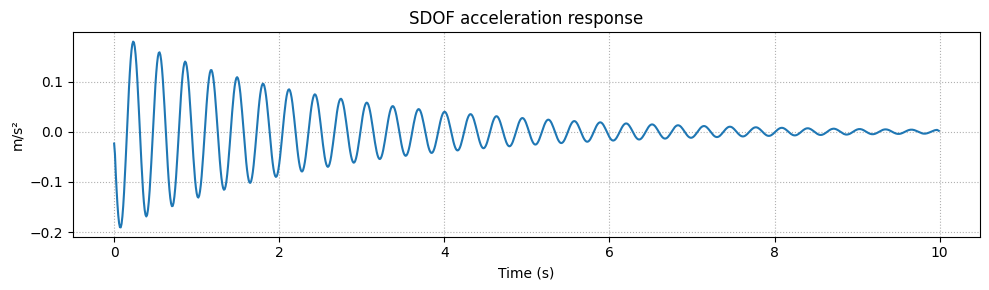

In [8]:
m, k, zeta = 1.0, 400.0, 0.02
omega_n = np.sqrt(k / m)
omega_d = omega_n * np.sqrt(1 - zeta**2)
h_disp  = np.exp(-zeta * omega_n * t) * np.sin(omega_d * t) / (m * omega_d)

exc_arr      = np.zeros(N); exc_arr[0] = 1.0
resp_disp    = fftconvolve(exc_arr, h_disp, mode="full")[:N] * DT
resp_acc     = np.gradient(np.gradient(resp_disp, DT), DT)

ts_resp = timeseries(
    measurements=resp_acc[:, np.newaxis, np.newaxis],
    time_step=DT, measurements_units="meter / second ** 2",
    method="SIMO", name="SDOF_accel",
    path="./_demo_ts_resp.h5",
)
ts_exc = timeseries(
    measurements=exc_arr[:, np.newaxis, np.newaxis],
    time_step=DT, measurements_units="newton",
    method="excitation", name="SDOF_force",
    path="./_demo_ts_exc.h5",
)

print(f"Duration       : {ts_resp.time_span:.2f} s")
print(f"Samples        : {ts_resp.measurements[0].shape[0]}")
print(f"time_step      : {ts_resp.time_step}  (Δt in seconds)")
print(f"sampling_rate  : {ts_resp.sampling_rate}  Hz")

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(ts_resp.time_array, ts_resp.measurements[0][()][:, 0, 0])
ax.set(title="SDOF acceleration response", xlabel="Time (s)", ylabel="m/s²")
ax.grid(True, linestyle=":")
plt.tight_layout(); plt.show()

In [9]:
# Augmentation operates on a multi-item collection: append noisy copies
ts_pop = timeseries(
    measurements=[resp_acc[:, None, None] + RNG.normal(0, 0.02, (N, 1, 1))
                  for _ in range(6)],
    time_step=DT, measurements_units="meter / second ** 2",
    method="SIMO", names=[f"run_{i:02d}" for i in range(6)],
    labels=[0.0] * 6, path="./_demo_ts_pop.h5",
)
print(f"Before augmentation: {len(ts_pop)} signals")
ts_pop.AddGaussianNoise(min_amplitude=0.005, max_amplitude=0.02)
print(f"After  augmentation: {len(ts_pop)} signals")
ts_pop.close()
ts_resp.close(); ts_exc.close()

Before augmentation: 6 signals


After  augmentation: 12 signals


## 4 · Multi-item `frf` — the same class, just a list

All 270 FRFs go into a single multi-item `frf` collection, written to one
HDF5 file. There is no separate `frf_collection` class anymore — `frf`
accepts either a single ndarray or a list of ndarrays.

In [10]:
COLL_PATH = Path("./demo_frfs.h5")

collection = frf(
    measurements=H_all,
    freq_resolution=DF,
    measurements_units="millimeter / second ** 2 / newton",
    freq_units="hertz",
    method="SIMO",
    names=names_all,
    labels=labels_all,
    path=COLL_PATH,
)
print(f"Collection : {len(collection)} FRFs  →  {COLL_PATH}")
print(f"Item shape : {collection.measurements[0].shape}")
print(f"Labels     : {sorted({lbl[()] for lbl in collection.labels})}")

Collection : 270 FRFs  →  demo_frfs.h5
Item shape : (501, 1, 1)
Labels     : [np.float64(0.0), np.float64(1.0), np.float64(2.0)]


In [11]:
# Batch-restrict every FRF to 0–25 Hz in place (one HDF5 file, mutated)
collection.change_freq_span(new_min_freq=0.0, new_max_freq=25.0)
n_freq_trimmed = collection.measurements[0].shape[0]
print(f"After change_freq_span: {n_freq_trimmed} frequency lines  (0–25 Hz)")

After change_freq_span: 251 frequency lines  (0–25 Hz)


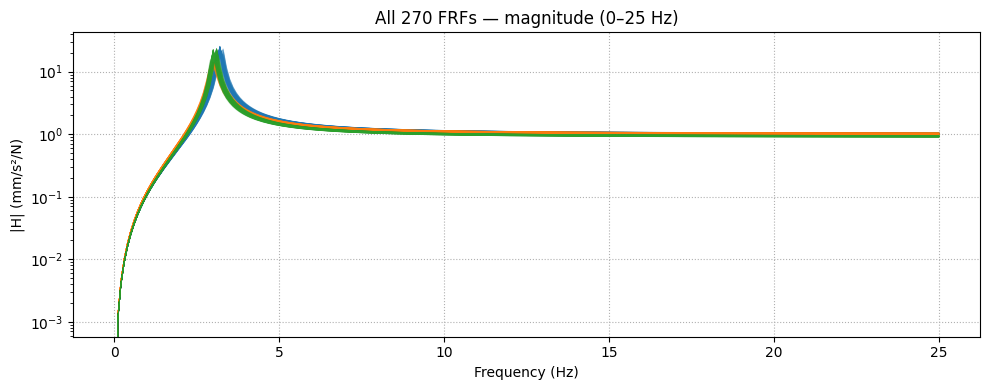

In [12]:
# Overlay plot — iterate over items
fig, ax = plt.subplots(figsize=(10, 4))
COLORS = {0: "tab:blue", 1: "tab:orange", 2: "tab:green"}
for i in range(len(collection)):
    arr = collection.measurements[i][()][:, 0, 0]
    lbl = int(collection.labels[i][()])
    ax.semilogy(collection.freq_array, np.abs(arr),
                color=COLORS[lbl], alpha=0.25, lw=0.6)
ax.set(title=f"All {len(collection)} FRFs — magnitude (0–25 Hz)",
       xlabel="Frequency (Hz)", ylabel="|H| (mm/s²/N)")
ax.grid(True, linestyle=":")
plt.tight_layout(); plt.show()

## 5 · PyTorch dataset and DataLoader

`.torch_dataset()` closes the collection's HDF5 file and wraps it in
`HDF5Dataset`, a `torch.utils.data.Dataset` that lazy-loads each sample
on demand and skips the `_axes` collection-metadata group.

In [13]:
def frf_to_tensor(x: np.ndarray) -> torch.Tensor:
    """complex (n_freq, n_out, n_in) → float32 (n_out*n_in, n_freq) log-magnitude."""
    mag = np.abs(x).astype(np.float32)
    mag = mag.reshape(mag.shape[0], -1).T
    return torch.from_numpy(np.log1p(mag))


collection.torch_dataset()
dataset = collection.dataset
dataset.transform = frf_to_tensor

x0, y0 = dataset[0]
print(f"Dataset size : {len(dataset)}")
print(f"Sample shape : {tuple(x0.shape)}   (channels, freq_lines)")
print(f"Label        : {y0.item()}")

Dataset size : 270
Sample shape : (1, 251)   (channels, freq_lines)
Label        : 1.0


In [14]:
n_total = len(dataset)
n_train = int(0.8 * n_total)
n_val   = n_total - n_train

gen = torch.Generator().manual_seed(42)
train_ds, val_ds = torch.utils.data.random_split(dataset, [n_train, n_val], generator=gen)

BATCH = 4
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=0)

xb, yb = next(iter(train_loader))
print(f"Batch shape : {tuple(xb.shape)}  labels: {yb.tolist()}")
print(f"Train batches: {len(train_loader)}  val batches: {len(val_loader)}")

Batch shape : (4, 1, 251)  labels: [2.0, 0.0, 1.0, 0.0]
Train batches: 54  val batches: 14


## 6 · Model — lightweight 1-D CNN

In [15]:
class FRF_CNN(nn.Module):
    def __init__(self, in_channels: int, n_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(in_channels, 16, kernel_size=7, padding=3), nn.BatchNorm1d(16), nn.ReLU(),
            nn.Conv1d(16,         32, kernel_size=5, padding=2), nn.BatchNorm1d(32), nn.ReLU(),
            nn.Conv1d(32,         64, kernel_size=3, padding=1), nn.BatchNorm1d(64), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Linear(64, n_classes)

    def forward(self, x):
        return self.classifier(self.features(x).squeeze(-1))


N_CHANNELS = x0.shape[0]
N_CLASSES  = 3
model = FRF_CNN(in_channels=N_CHANNELS, n_classes=N_CLASSES).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"Parameters : {n_params:,}")

Parameters : 9,347


## 7 · Training — gradient accumulation + mixed precision

In [16]:
EPOCHS      = 20
LR          = 1e-3
ACCUM       = 4
AMP_ENABLED = DEVICE.type == "cuda"

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler    = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)

train_losses, val_accs = [], []

for epoch in range(1, EPOCHS + 1):
    model.train(); optimizer.zero_grad(); ep_loss = 0.0
    for step, (x, y) in enumerate(train_loader, 1):
        x, y = x.to(DEVICE), y.long().to(DEVICE)
        with torch.amp.autocast(device_type=DEVICE.type, enabled=AMP_ENABLED):
            loss = criterion(model(x), y) / ACCUM
        scaler.scale(loss).backward()
        if step % ACCUM == 0 or step == len(train_loader):
            scaler.step(optimizer); scaler.update(); optimizer.zero_grad()
        ep_loss += loss.item() * ACCUM
    train_losses.append(ep_loss / len(train_loader))

    model.eval(); correct = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(DEVICE), y.long().to(DEVICE)
            with torch.amp.autocast(device_type=DEVICE.type, enabled=AMP_ENABLED):
                preds = model(x).argmax(1)
            correct += (preds == y).sum().item()
    val_accs.append(correct / n_val)
    scheduler.step()
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS}  loss={train_losses[-1]:.4f}  val_acc={val_accs[-1]:.3f}")
print("Training complete.")

Epoch   1/20  loss=1.0315  val_acc=0.481


Epoch   5/20  loss=0.7421  val_acc=0.574


Epoch  10/20  loss=0.6952  val_acc=1.000


Epoch  15/20  loss=0.6309  val_acc=1.000


Epoch  20/20  loss=0.5933  val_acc=1.000
Training complete.


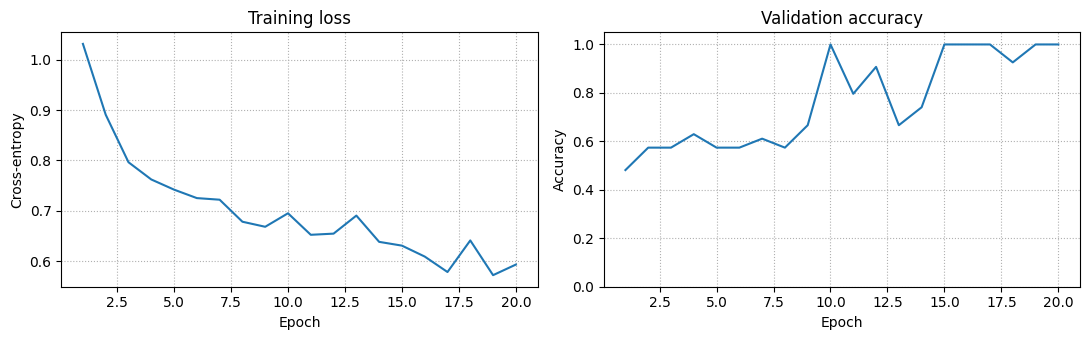

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5))
ax1.plot(range(1, EPOCHS + 1), train_losses)
ax1.set(title="Training loss", xlabel="Epoch", ylabel="Cross-entropy")
ax2.plot(range(1, EPOCHS + 1), val_accs)
ax2.set(title="Validation accuracy", xlabel="Epoch", ylabel="Accuracy", ylim=(0, 1.05))
for ax in (ax1, ax2):
    ax.grid(True, linestyle=":")
plt.tight_layout(); plt.show()

## 8 · Evaluation — confusion matrix

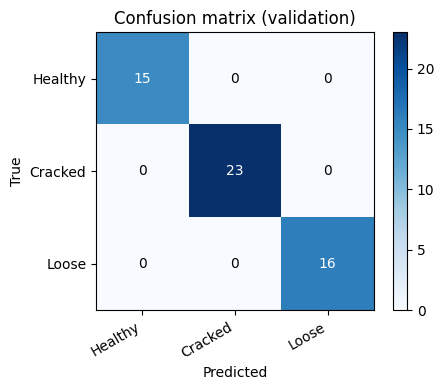

Validation accuracy : 100.0%


In [18]:
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for x, y in val_loader:
        x = x.to(DEVICE)
        with torch.amp.autocast(device_type=DEVICE.type, enabled=AMP_ENABLED):
            preds = model(x).argmax(1).cpu()
        all_preds.extend(preds.tolist()); all_true.extend(y.tolist())

CLASS_NAMES = [cls["tag"] for cls in CLASS_DEFS]
n_cls = len(CLASS_NAMES)
cm = np.zeros((n_cls, n_cls), dtype=int)
for tt, pp in zip(all_true, all_preds):
    cm[int(tt), int(pp)] += 1

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(n_cls)); ax.set_xticklabels(CLASS_NAMES, rotation=30, ha="right")
ax.set_yticks(range(n_cls)); ax.set_yticklabels(CLASS_NAMES)
ax.set(xlabel="Predicted", ylabel="True", title="Confusion matrix (validation)")
for i in range(n_cls):
    for j in range(n_cls):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()
print(f"Validation accuracy : {np.trace(cm)/cm.sum():.1%}")

## 10 · `cfdac_collection` — typed 2-D indicator

CFDAC is a 2-D indicator (`(N_DOF, N_DOF)` per item). After the refactor,
it lives in its own typed class `cfdac_collection`, a subclass of
`_collection_2d`. The `(reference, damaged)` pair is stored automatically
under `/references/{reference,damaged}/` in the indicator's HDF5 file —
`get_reference_data` recovers either source FRF for any item.

We compare two classifiers on a coupled 8-DOF chain:

| Model | Input | Architecture |
|---|---|---|
| Baseline | log \|H(ω)\| — (8 × n_freq) | 1-D CNN, 8 channels |
| CFDAC    | \|CFDAC\| matrix — (1 × 8 × 8) | 2-D CNN, 1 channel |

In [19]:
N_DOF  = 8
M_BASE = np.ones(N_DOF)
K_BASE = np.full(N_DOF + 1, 2000.0)

CHAIN_DEFS = [
    {"label": 0, "tag": "Healthy",
     "dm": np.ones(N_DOF), "dk": np.ones(N_DOF + 1)},
    {"label": 1, "tag": "Crack_56",
     "dm": np.ones(N_DOF),
     "dk": np.array([1.0, 1.0, 1.0, 1.0, 1.0, 0.70, 1.0, 1.0, 1.0])},
    {"label": 2, "tag": "Mass_67",
     "dm": np.array([1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.30, 1.30]),
     "dk": np.ones(N_DOF + 1)},
]


def build_chain(m_vec, k_springs, z0=0.020):
    N = len(m_vec)
    M_mat = np.diag(m_vec.astype(float))
    K_mat = np.zeros((N, N))
    for i in range(N):
        K_mat[i, i] += k_springs[i] + k_springs[i + 1]
        if i > 0:
            K_mat[i, i - 1] -= k_springs[i]
            K_mat[i - 1,  i] -= k_springs[i]
    omega_ref = np.sqrt(np.maximum(np.linalg.eigvalsh(K_mat), 0).mean())
    C_mat = (2 * z0 / max(omega_ref, 1e-6)) * K_mat
    return M_mat, C_mat, K_mat


def chain_frf(omega, M_mat, C_mat, K_mat, input_dof=0):
    N = M_mat.shape[0]
    F = np.zeros(N); F[input_dof] = 1.0
    D = (-omega**2)[:, None, None] * M_mat + 1j * omega[:, None, None] * C_mat + K_mat
    H_disp = np.linalg.solve(D, F)
    return (-omega**2)[:, None] * H_disp


def chain_sample(omega, dm, dk, rng):
    sm = rng.uniform(0.88, 1.12, N_DOF)
    sk = rng.uniform(0.88, 1.12, N_DOF + 1)
    M_mat, C_mat, K_mat = build_chain(M_BASE * dm * sm, K_BASE * dk * sk)
    return chain_frf(omega, M_mat, C_mat, K_mat)[:, :, np.newaxis].astype(np.complex64)


RNG_CHAIN = np.random.default_rng(13)
H_chain, labels_chain, names_chain = [], [], []
for cls in CHAIN_DEFS:
    for i in range(N_PER_CLASS):
        H_chain.append(chain_sample(omega, cls["dm"], cls["dk"], RNG_CHAIN))
        labels_chain.append(float(cls["label"]))
        names_chain.append(f"{cls['tag']}_{i:03d}")

print(f"Generated {len(H_chain)} coupled-chain FRFs — per-FRF shape {H_chain[0].shape}")

Generated 270 coupled-chain FRFs — per-FRF shape (501, 8, 1)


In [20]:
CHAIN_PATH = Path("./demo_chain.h5")
CFDAC_PATH = Path("./demo_cfdac.h5")
REF_PATH   = Path("./demo_ref.h5")

# Baseline reference: mean over all healthy realisations (cleaner than any
# single one). We package it as a 1-item frf collection so it can be passed
# to the indicator method.
healthy_frfs = [H_chain[i] for i in range(N_PER_CLASS)]
ref_mean     = np.mean(healthy_frfs, axis=0).astype(np.complex64)
ref_chain = frf(
    measurements=ref_mean, freq_resolution=DF,
    measurements_units="millimeter / second ** 2 / newton",
    freq_units="hertz", method="SIMO", name="reference_healthy",
    path=REF_PATH,
)

# Multi-item chain FRF collection — one item per realisation
chain_col = frf(
    measurements=H_chain,
    freq_resolution=DF,
    measurements_units="millimeter / second ** 2 / newton",
    freq_units="hertz",
    method="SIMO",
    names=names_chain,
    labels=labels_chain,
    path=CHAIN_PATH,
)
chain_col.change_freq_span(new_min_freq=0.0, new_max_freq=25.0)
ref_chain.change_freq_span(new_min_freq=0.0, new_max_freq=25.0)

# 70/15/15 stratified split, mirrored onto the indicator below
chain_col.split(train_frac=0.70, val_frac=0.15, test_frac=0.15, seed=42)
print(f"Chain collection : {len(chain_col)} signals × {N_DOF} DOFs × "
      f"{chain_col.measurements[0].shape[0]} freq lines")
print(f"  train={len(chain_col.train_indices)}  "
      f"val={len(chain_col.val_indices)}  "
      f"test={len(chain_col.test_indices)}")

# Indicator method on damaged (`chain_col`) against reference (`ref_chain`)
# — the resulting `cfdac_collection` carries both FRFs as embedded references.
cfdac_col = chain_col.cfdac(ref_chain, path=CFDAC_PATH)
cfdac_col.train_indices = chain_col.train_indices
cfdac_col.val_indices   = chain_col.val_indices
cfdac_col.test_indices  = chain_col.test_indices

print(f"CFDAC collection : {len(cfdac_col)} items, item shape "
      f"{cfdac_col.measurements[0].shape}  (D1, D2, n_out, n_in)")
print(f"reference roles  : {cfdac_col.reference_roles()}")
print(f"recovered ref shape (item 0): "
      f"{cfdac_col.get_reference_data('reference', 0).shape}")

Chain collection : 270 signals × 8 DOFs × 251 freq lines
  train=189  val=42  test=39


CFDAC collection : 270 items, item shape (8, 8, 1, 1)  (D1, D2, n_out, n_in)
reference roles  : ['reference', 'damaged']
recovered ref shape (item 0): (251, 8, 1)


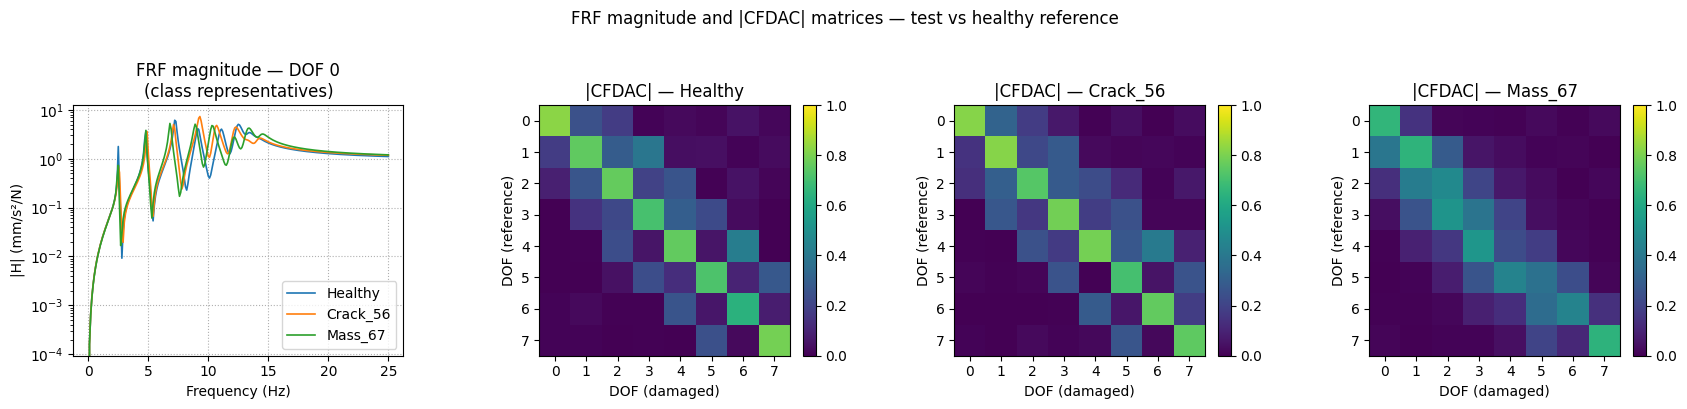

In [21]:
COLORS_CH = ["tab:blue", "tab:orange", "tab:green"]
fig, axes = plt.subplots(1, 4, figsize=(17, 4))
freq_ch = chain_col.freq_array

ax_frf = axes[0]
for cls, col in zip(CHAIN_DEFS, COLORS_CH):
    idx  = int(cls["label"] * N_PER_CLASS)
    data = chain_col.measurements[idx][()]
    ax_frf.semilogy(freq_ch, np.abs(data[:, 0, 0]), label=cls["tag"], color=col, lw=1.2)
ax_frf.set(title="FRF magnitude — DOF 0\n(class representatives)",
           xlabel="Frequency (Hz)", ylabel="|H| (mm/s²/N)")
ax_frf.legend(); ax_frf.grid(True, linestyle=":")

for ax, cls in zip(axes[1:], CHAIN_DEFS):
    idx  = int(cls["label"] * N_PER_CLASS)
    data = cfdac_col.measurements[idx][()]
    mat  = np.abs(data[:, :, 0, 0])
    im   = ax.imshow(mat, cmap="viridis", vmin=0, vmax=1)
    ax.set(title=f"|CFDAC| — {cls['tag']}", xlabel="DOF (damaged)", ylabel="DOF (reference)")
    ax.set_xticks(range(N_DOF)); ax.set_yticks(range(N_DOF))
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.suptitle("FRF magnitude and |CFDAC| matrices — test vs healthy reference", y=1.01)
plt.tight_layout(); plt.show()

In [22]:
def run_training(model, tr_ldr, va_ldr, n_val, epochs=15, lr=1e-3, accum=4):
    crit   = nn.CrossEntropyLoss()
    opt    = torch.optim.Adam(model.parameters(), lr=lr)
    sched  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    scaler = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)
    losses, accs = [], []
    for ep in range(1, epochs + 1):
        model.train(); opt.zero_grad(); ep_loss = 0.0
        for step, (x, y) in enumerate(tr_ldr, 1):
            x, y = x.to(DEVICE), y.long().to(DEVICE)
            with torch.amp.autocast(device_type=DEVICE.type, enabled=AMP_ENABLED):
                loss = crit(model(x), y) / accum
            scaler.scale(loss).backward()
            if step % accum == 0 or step == len(tr_ldr):
                scaler.step(opt); scaler.update(); opt.zero_grad()
            ep_loss += loss.item() * accum
        losses.append(ep_loss / len(tr_ldr))
        model.eval(); correct = 0
        with torch.no_grad():
            for x, y in va_ldr:
                x, y = x.to(DEVICE), y.long().to(DEVICE)
                with torch.amp.autocast(device_type=DEVICE.type, enabled=AMP_ENABLED):
                    correct += (model(x).argmax(1) == y).sum().item()
        accs.append(correct / n_val)
        sched.step()
        if ep % 5 == 0 or ep == 1:
            print(f"  ep {ep:3d}/{epochs}  loss={losses[-1]:.4f}  val_acc={accs[-1]:.3f}")
    return losses, accs


def eval_confusion(model, loader, n_cls=3):
    model.eval(); cm = np.zeros((n_cls, n_cls), dtype=int)
    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            with torch.amp.autocast(device_type=DEVICE.type, enabled=AMP_ENABLED):
                preds = model(x).argmax(1).cpu()
            for tt, pp in zip(y.tolist(), preds.tolist()):
                cm[int(tt), int(pp)] += 1
    return cm

In [23]:
# ── Baseline 1-D CNN over multi-DOF FRF ───────────────────────────────────
def frf_to_tensor_md(x: np.ndarray) -> torch.Tensor:
    """(n_freq, N_DOF, 1) complex → (N_DOF, n_freq) float32 log-magnitude."""
    mag = np.abs(x[:, :, 0]).astype(np.float32)
    return torch.from_numpy(np.log1p(mag).T)


chain_col.torch_dataset()
chain_ds = chain_col.dataset
chain_ds.transform = frf_to_tensor_md

x_ch, _ = chain_ds[0]
print(f"Baseline input shape : {tuple(x_ch.shape)}  (N_DOF, n_freq)")

tr_ch = torch.utils.data.Subset(chain_ds, chain_col.train_indices)
va_ch = torch.utils.data.Subset(chain_ds, chain_col.val_indices)
te_ch = torch.utils.data.Subset(chain_ds, chain_col.test_indices)
ldr_tr_ch = DataLoader(tr_ch, batch_size=BATCH, shuffle=True,  num_workers=0)
ldr_va_ch = DataLoader(va_ch, batch_size=BATCH, shuffle=False, num_workers=0)
ldr_te_ch = DataLoader(te_ch, batch_size=BATCH, shuffle=False, num_workers=0)

baseline = FRF_CNN(in_channels=N_DOF, n_classes=N_CLASSES).to(DEVICE)
print(f"Baseline params      : {sum(p.numel() for p in baseline.parameters()):,}\n--- Baseline training ---")
bl_losses, bl_accs = run_training(baseline, ldr_tr_ch, ldr_va_ch, len(va_ch))
cm_bl = eval_confusion(baseline, ldr_te_ch)
print(f"\nBaseline TEST accuracy: {np.trace(cm_bl)/cm_bl.sum():.1%}")

Baseline input shape : (8, 251)  (N_DOF, n_freq)
Baseline params      : 10,131
--- Baseline training ---


  ep   1/15  loss=1.0500  val_acc=0.833


  ep   5/15  loss=0.7369  val_acc=0.881


  ep  10/15  loss=0.5509  val_acc=0.857


  ep  15/15  loss=0.4928  val_acc=0.881

Baseline TEST accuracy: 89.7%


In [24]:
# ── CFDAC 2-D CNN ─────────────────────────────────────────────────────────
class CFDAC_CNN(nn.Module):
    def __init__(self, n_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Linear(64, n_classes)

    def forward(self, x):
        return self.classifier(self.features(x).squeeze(-1).squeeze(-1))


def cfdac_to_tensor(x: np.ndarray) -> torch.Tensor:
    """(N_DOF, N_DOF, 1, 1) complex → (1, N_DOF, N_DOF) float32 magnitude."""
    mat = np.abs(x[:, :, 0, 0]).astype(np.float32)
    return torch.from_numpy(mat[np.newaxis])


cfdac_col.torch_dataset()
cfdac_ds = cfdac_col.dataset
cfdac_ds.transform = cfdac_to_tensor

x_cf, _ = cfdac_ds[0]
print(f"CFDAC input shape : {tuple(x_cf.shape)}  (1, N_DOF, N_DOF)")

tr_cf = torch.utils.data.Subset(cfdac_ds, cfdac_col.train_indices)
va_cf = torch.utils.data.Subset(cfdac_ds, cfdac_col.val_indices)
te_cf = torch.utils.data.Subset(cfdac_ds, cfdac_col.test_indices)
ldr_tr_cf = DataLoader(tr_cf, batch_size=BATCH, shuffle=True,  num_workers=0)
ldr_va_cf = DataLoader(va_cf, batch_size=BATCH, shuffle=False, num_workers=0)
ldr_te_cf = DataLoader(te_cf, batch_size=BATCH, shuffle=False, num_workers=0)

cfdac_md = CFDAC_CNN(N_CLASSES).to(DEVICE)
print(f"CFDAC model params : {sum(p.numel() for p in cfdac_md.parameters()):,}\n--- CFDAC CNN training ---")
cf_losses, cf_accs = run_training(cfdac_md, ldr_tr_cf, ldr_va_cf, len(va_cf))
cm_cf = eval_confusion(cfdac_md, ldr_te_cf)
print(f"\nCFDAC TEST accuracy : {np.trace(cm_cf)/cm_cf.sum():.1%}")

CFDAC input shape : (1, 8, 8)  (1, N_DOF, N_DOF)
CFDAC model params : 23,715
--- CFDAC CNN training ---


  ep   1/15  loss=0.9326  val_acc=0.548


  ep   5/15  loss=0.5574  val_acc=0.857


  ep  10/15  loss=0.3863  val_acc=0.929


  ep  15/15  loss=0.3790  val_acc=0.952

CFDAC TEST accuracy : 100.0%


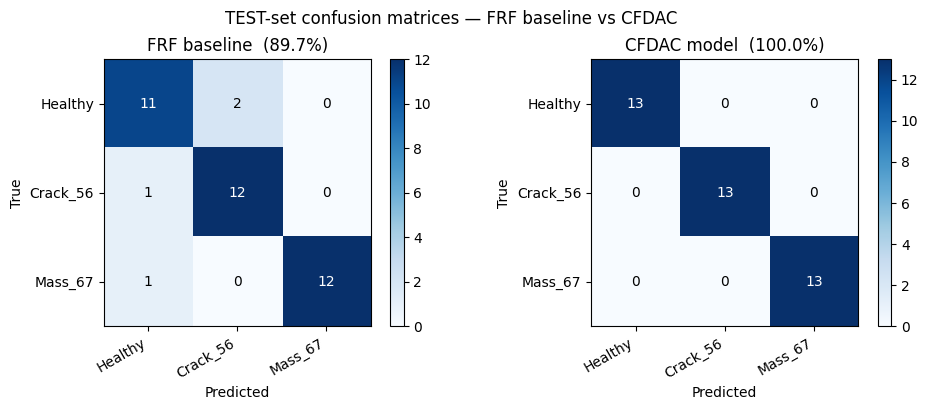

In [25]:
CLASS_NAMES_CH = [cls["tag"] for cls in CHAIN_DEFS]
acc_bl = np.trace(cm_bl) / cm_bl.sum()
acc_cf = np.trace(cm_cf) / cm_cf.sum()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, cm_val, title in zip(
    axes,
    [cm_bl, cm_cf],
    [f"FRF baseline  ({acc_bl:.1%})", f"CFDAC model  ({acc_cf:.1%})"],
):
    im = ax.imshow(cm_val, cmap="Blues")
    ax.set_xticks(range(N_CLASSES)); ax.set_xticklabels(CLASS_NAMES_CH, rotation=30, ha="right")
    ax.set_yticks(range(N_CLASSES)); ax.set_yticklabels(CLASS_NAMES_CH)
    ax.set(xlabel="Predicted", ylabel="True", title=title)
    for i in range(N_CLASSES):
        for j in range(N_CLASSES):
            ax.text(j, i, cm_val[i, j], ha="center", va="center",
                    color="white" if cm_val[i, j] > cm_val.max() / 2 else "black")
    fig.colorbar(im, ax=ax)
fig.suptitle("TEST-set confusion matrices — FRF baseline vs CFDAC")
plt.tight_layout(); plt.show()

## 9 · Cleanup

In [26]:
for p in (COLL_PATH, CHAIN_PATH, CFDAC_PATH, REF_PATH,
          Path("./_demo_proc.h5"),
          Path("./_demo_ts_resp.h5"), Path("./_demo_ts_exc.h5"),
          Path("./_demo_ts_pop.h5")):
    p.unlink(missing_ok=True)
print("Removed demo HDF5 files.")

Removed demo HDF5 files.
